# Data Loading

In [16]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, RepeatedKFold

In [17]:
vosoughi_false_df = pd.read_csv('./rq2_vosoughi_False_features.csv', index_col=0, sep=',', encoding='utf-8')
vosoughi_true_df = pd.read_csv('./rq2_vosoughi_True_features.csv', index_col=0, sep=',', encoding='utf-8')
vosoughi_df = pd.concat([vosoughi_false_df, vosoughi_true_df])
# vosoughi_df = vosoughi_false_df
vosoughi_df.shape

(107015, 16)

In [18]:
filtered_df = vosoughi_df[(vosoughi_df.characteristic_distance != -99999) & (vosoughi_df.depth != 0)]
filtered_df.shape

(38007, 16)

In [19]:
filtered_df.groupby(['veracity']).count()

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,,,,,
0.0,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858
1.0,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149


In [21]:
31858/38006, 6149/38006

(0.8382360679892649, 0.16179024364574016)

In [5]:
filtered_df[(filtered_df.characteristic_distance != -99999) & (filtered_df.depth != 0)].groupby(['veracity']).count()

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,,,,,
0.0,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858
1.0,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149


In [6]:
filtered_df.drop(['cascade_root_id', 'time_bucket', 'weakly_cc', 'avg_cluster_coef'], axis=1, inplace=True)
filtered_df

C:\Users\siddiquee\AppData\Local\Temp\ipykernel_2256\2554505585.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.drop(['cascade_root_id', 'time_bucket', 'weakly_cc', 'avg_cluster_coef'], axis=1, inplace=True)


,cascade_id,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
50748,50748.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50749,50749.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50750,50750.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50751,50751.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50752,50752.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6144,88733.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0
6145,88734.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0
6146,88735.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0
6147,88736.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0


In [48]:
filtered_df['size'].describe()

count    38007.000000
mean        96.263451
std        979.578537
min          2.000000
25%          2.000000
50%          4.000000
75%          9.000000
max      46895.000000
Name: size, dtype: float64

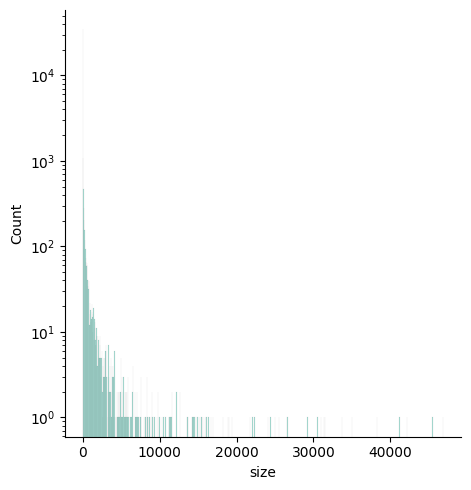

In [15]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.set_palette("Set3")
sns.displot(filtered_df, x="size", bins=1000)
# plt.xscale('log')
plt.yscale('log')
plt.savefig('./size_distribution_vosoughi.pdf', format='pdf')

In [47]:
Q1 = filtered_df['size'].quantile(0.25)
Q3 = filtered_df['size'].quantile(0.75)

Q1, Q3

(2.0, 9.0)

In [23]:
a = list(set([i for i in filtered_df['size'].to_list()]))
import numpy as np 
# a = np.array([i for i in filtered_df['size'].to_list()])
print(np.quantile(a, 0.25))
print(np.quantile(a, 0.75))
np.median(a)

325.5
2140.5


787.0

In [24]:
len([i for i in filtered_df['size'].to_list() if i < np.quantile(a, 0.25)]), len([i for i in filtered_df['size'].to_list() if i >= np.quantile(a, 0.25)])

(36744, 324)

In [12]:
smaller_df = filtered_df[filtered_df['size'] < np.median(a)]
print(smaller_df.shape)
smaller_df[(smaller_df.characteristic_distance != -99999) & (smaller_df.depth != 0)].groupby(['veracity']).count()

(37310, 12)


,cascade_id,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,
0.0,31204,31204,31204,31204,31204,31204,31204,31204,31204,31204,31204
1.0,6106,6106,6106,6106,6106,6106,6106,6106,6106,6106,6106


In [13]:
bigger_df = filtered_df[filtered_df['size'] >= np.median(a)]
print(bigger_df.shape)
bigger_df[(bigger_df.characteristic_distance != -99999) & (bigger_df.depth != 0)].groupby(['veracity']).count()

(697, 12)


,cascade_id,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,
0.0,654,654,654,654,654,654,654,654,654,654,654
1.0,43,43,43,43,43,43,43,43,43,43,43


In [70]:
filtered_df.groupby(['size'])['cascade_id'].count().to_csv('./size_wise_count.csv')

In [77]:
filtered_df[filtered_df['size'] <= Q1].shape, filtered_df[filtered_df['size'] >= Q3].shape

((11412, 16), (10195, 16))

In [5]:
vosoughi_df[vosoughi_df.cascade_root_id.duplicated()]

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity


In [26]:
filtered_df

,cascade_id,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
50748,50748.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50749,50749.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50750,50750.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50751,50751.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
50752,50752.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6144,88733.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0
6145,88734.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0
6146,88735.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0
6147,88736.0,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579,1.0


In [31]:
smaller_df.iloc[:, 1:11]

,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
50748,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
50749,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
50750,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
50751,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
50752,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
...,...,...,...,...,...,...,...,...,...,...
6144,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
6145,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
6146,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579
6147,1.0,2.0,2.0,0.5,2.0,2.0,0.5,1.0,1.0,1.439579


In [35]:
active_features = 11
X = bigger_df.iloc[:, 1:active_features]
Y = bigger_df.iloc[:,active_features]
# split data into train and test sets
seed = 7
test_size = 0.10
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape

((627, 10), (70, 10), (627,), (70,))

In [36]:
import pickle 

with open("./RQ3Final2/RQ3Final2_x_train_val.pickle", "wb") as file:
    pickle.dump(X_train_val, file)

with open("./RQ3Final2/RQ3Final2_y_train_val.pickle", "wb") as file:
    pickle.dump(y_train_val, file)

with open("./RQ3Final2/RQ3Final2_x_test.pickle", "wb") as file:
    pickle.dump(X_test, file)

with open("./RQ3Final2/RQ3Final2_y_test.pickle", "wb") as file:
    pickle.dump(y_test, file)

In [10]:
# considered_features = ['max_breadth', 'density', 'virality', 'depth', 'structural_heterogeneity', 'characteristic_distance', 'size_of_scc', 'layer_ratio']
# X_train_val[considered_features]
X_train_val

,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
82010,6.0,901.0,424.0,0.002939,901.0,901.0,0.001110,2.142857,6.684196,0.000000
82152,4.0,1450.0,1278.0,0.000883,1450.0,1450.0,0.000690,1.120501,16.791515,0.546498
82191,4.0,1616.0,1534.0,0.000694,1616.0,1616.0,0.000619,1.047588,19.086841,0.000000
82460,9.0,4943.0,3360.0,0.000482,4943.0,4943.0,0.000202,1.293155,23.905158,0.000000
82337,8.0,2669.0,1108.0,0.001349,2669.0,2669.0,0.000375,1.805054,10.939911,0.000000
...,...,...,...,...,...,...,...,...,...,...
82531,15.0,8386.0,1707.0,0.001271,8386.0,8386.0,0.000119,1.971880,9.753681,0.000000
82454,5.0,4936.0,3777.0,0.000324,4936.0,4936.0,0.000203,1.262642,26.955259,0.704224
82489,7.0,5910.0,4379.0,0.000318,5910.0,5910.0,0.000169,1.248230,28.488642,0.000000
82148,5.0,1417.0,1178.0,0.001077,1417.0,1417.0,0.000706,1.151952,15.665165,0.734953


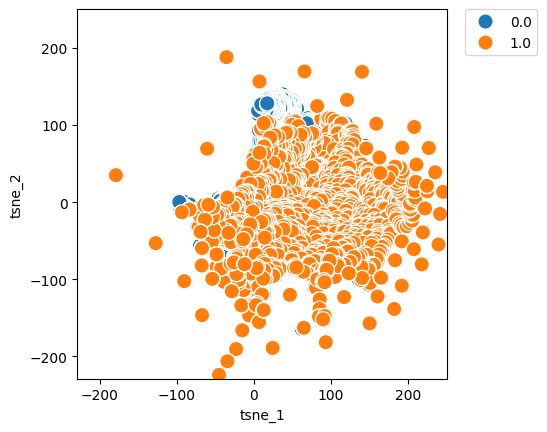

In [10]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
# We want to get TSNE embedding with 2 dimensions
n_components = 2
tsne = TSNE(n_components)
tsne_result = tsne.fit_transform(scaled_X_train)
tsne_result.shape
# (1000, 2)
# Two dimensions for each of our images
 
# Plot the result of our TSNE with the label color coded
# A lot of the stuff here is about making the plot look pretty and not TSNE
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': Y})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

# load from Pickle

In [64]:
import os 
import pickle

prefix = '../datasets-for-exp/RQ4Final1/RQ4Final1_'

with open(prefix + 'x_train_val.pickle', "rb") as file:
    X_train_val = pickle.load(file)

with open(prefix + 'y_train_val.pickle' , "rb") as file:
    y_train_val = pickle.load(file)

with open(prefix + 'x_test.pickle',  "rb") as file:
    X_test = pickle.load(file)

with open(prefix + 'y_test.pickle',  "rb") as file:
    y_test = pickle.load(file)


# drop them only for fibvid 
# X_train_val.drop(['strongly_cc', 'size_of_scc', 'weakly_cc', 'avg_cluster_coef'], axis=1, inplace=True)
# X_test.drop(['strongly_cc', 'size_of_scc', 'weakly_cc', 'avg_cluster_coef'], axis=1, inplace=True)
# X_train_val = X_train_val.iloc[:, 1:len(list(X_train_val))]
# X_test = X_test.iloc[:, 1:len(list(X_test))]


# for vosoughi run this
# X_train_val.drop(['strongly_cc', 'size_of_scc'], axis=1, inplace=True)
# X_test.drop(['strongly_cc', 'size_of_scc'], axis=1, inplace=True)


X_train_val.shape, y_train_val.shape, X_test.shape, y_test.shape
# X_train_val[X_train_val['characteristic_distance'] == 0].shape[0] + X_test[X_test['characteristic_distance'] == 0].shape[0]


((1198, 10), (1198,), (212, 10), (212,))

In [42]:
X_train_val.columns

Index(['cascade_root_id', 'category', 'unique_user_count', 'depth', 'size',
       'max_breadth', 'virality', 'strongly_cc', 'weakly_cc', 'size_of_scc',
       'avg_cluster_coef', 'density', 'layer_ratio',
       'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')

In [53]:
with open(prefix + "x_train_val.pickle", "wb") as file:
    pickle.dump(X_train_val, file)

with open(prefix + "y_train_val.pickle", "wb") as file:
    pickle.dump(y_train_val, file)

with open(prefix + "x_test.pickle", "wb") as file:
    pickle.dump(X_test, file)

with open(prefix + "y_test.pickle", "wb") as file:
    pickle.dump(y_test, file)

In [15]:
# vosoughi ratio 
(0.8382360679892649, 0.16179024364574016) 4.19:0.81, 
# fibvid ratio
(0.7829787234042553, 0.2170212765957447) 3.132:0.868

0.9

In [4]:
X_train_val.columns

Index(['depth', 'size', 'max_breadth', 'virality', 'strongly_cc',
       'size_of_scc', 'density', 'layer_ratio', 'structural_heterogeneity',
       'characteristic_distance'],
      dtype='object')

In [70]:
X_train_val = X_train_val.iloc[:, 2:len(list(X_test))]

In [52]:

import numpy as np
from sklearn.preprocessing import StandardScaler
from copy import copy

normalized_df = copy(X_train_val)

# run this for vosoughi only
# cd_first_quantile = np.quantile(normalized_df['characteristic_distance'], 0.25)
# cd_third_quantile = np.quantile(normalized_df['characteristic_distance'], 0.75)
# normalized_df['characteristic_distance'] = np.log(normalized_df['characteristic_distance'] + cd_first_quantile**2/cd_third_quantile)

normalized_df['characteristic_distance'] = np.log(normalized_df['characteristic_distance'])

# scaler = StandardScaler().set_output(transform="pandas")
# scaled_X_train = scaler.fit_transform(normalized_df)


C:\Users\siddiquee\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [56]:
np.log(0)

C:\Users\siddiquee\AppData\Local\Temp\ipykernel_11272\2933082444.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


-inf

In [58]:
X_train_val[X_train_val['characteristic_distance'] == 0].shape


(360, 8)

In [67]:
X_train_val

,category,unique_user_count,depth,size,max_breadth,virality,density,layer_ratio,structural_heterogeneity,characteristic_distance
786,covid_false,148,0.006757,1.013514,1.013514,0.000045,0.000045,0.006757,0.041515,0.844590
507,covid_false,16,0.125000,1.000000,0.812500,0.005469,0.003906,0.076923,0.109924,0.074490
433,covid_false,73,0.027397,1.000000,0.931507,0.000214,0.000188,0.014706,0.054994,0.010185
892,covid_false,16,0.062500,1.000000,1.000000,0.003906,0.003906,0.062500,0.129099,0.976229
492,covid_false,12,0.083333,1.000000,1.000000,0.006944,0.006944,0.083333,0.150756,0.946358
...,...,...,...,...,...,...,...,...,...,...
266,covid_true,103,0.038835,1.058252,0.990291,0.000109,0.000089,0.010185,0.047700,0.007675
640,covid_false,118,0.025424,1.000000,0.822034,0.000203,0.000072,0.056830,0.039321,0.008030
684,covid_false,661,0.004539,1.049924,0.844175,0.000012,0.000002,0.015827,0.006897,0.021997
1549,non_covid_false,144,0.020833,1.027778,0.708333,0.000079,0.000047,0.009872,0.029841,0.005443


# Data cleaning

In [95]:
filtered_df

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
50748,666884.0,50748.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50749,666886.0,50749.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50750,666889.0,50750.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50751,666891.0,50751.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50752,666893.0,50752.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6144,4022213.0,88733.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0
6145,4022215.0,88734.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0
6146,4022217.0,88735.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0
6147,4022219.0,88736.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0


In [71]:
import pandas as pd
from matplotlib.cbook import boxplot_stats

d = [boxplot_stats(X_train_val[col].dropna().values)[0] for col in X_train_val.columns]
s = pd.DataFrame(d, index=X_train_val.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)
s["min"]=round(X_train_val.min(), 2)
s["max"]=round(X_train_val.max(), 2)
s["mean"]=round(X_train_val.mean(), 2)
s["median"]=round(X_train_val.median(), 2)
s["var"]=round(X_train_val.var(), 2)
s["std"]=round(X_train_val.std(), 2)
s

,whishi,whislo,q1,med,q3,min,max,mean,median,var,std
depth,0.16,0.00,0.01,0.02,0.07,0.00,0.67,0.06,0.02,1.000000e-02,0.08
size,1.09,1.00,1.00,1.01,1.04,1.00,1.50,1.03,1.01,0.000000e+00,0.04
max_breadth,1.22,0.62,0.85,1.00,1.00,0.28,1.40,0.90,1.00,3.000000e-02,0.19
virality,0.01,0.00,0.00,0.00,0.00,0.00,0.25,0.01,0.00,0.000000e+00,0.03
density,0.01,0.00,0.00,0.00,0.00,0.00,0.25,0.01,0.00,0.000000e+00,0.03
layer_ratio,0.13,0.00,0.01,0.02,0.06,0.00,0.50,0.05,0.02,1.000000e-02,0.07
structural_heterogeneity,0.25,0.00,0.04,0.06,0.12,0.00,0.50,0.09,0.06,1.000000e-02,0.08
characteristic_distance,1.51,0.00,0.01,0.72,0.96,0.00,25209834.09,91392.00,0.72,1.749248e+12,1322591.21


C:\Users\siddiquee\AppData\Local\Temp\ipykernel_10264\224106496.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box_plot.set_xticklabels(box_plot.get_xticklabels(), rotation=30)


[Text(0, 0, 'depth'),
 Text(1, 0, 'size'),
 Text(2, 0, 'max_breadth'),
 Text(3, 0, 'virality'),
 Text(4, 0, 'density'),
 Text(5, 0, 'layer_ratio'),
 Text(6, 0, 'structural_heterogeneity'),
 Text(7, 0, 'characteristic_distance')]

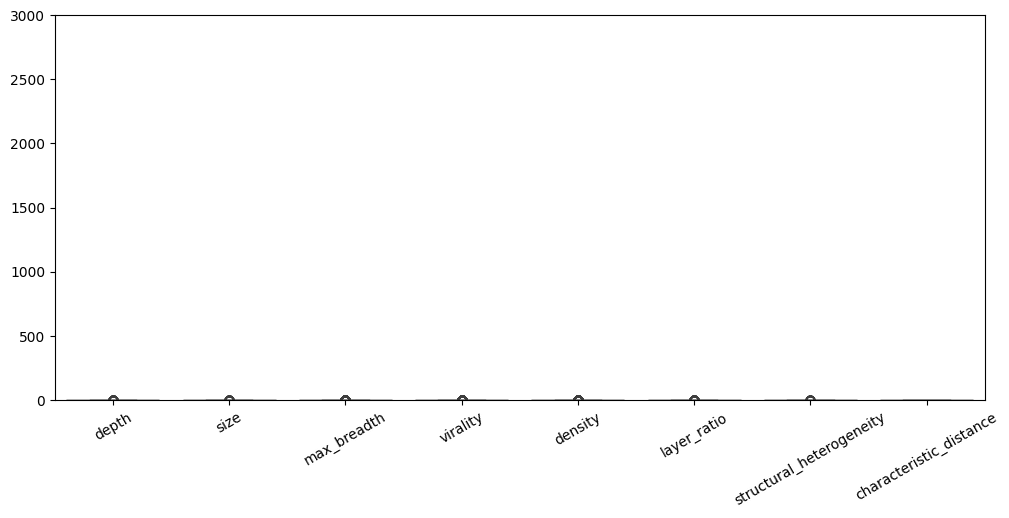

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.cbook import boxplot_stats

d = [boxplot_stats(X_train_val[col].dropna().values)[0] for col in X_train_val.columns]
s = pd.DataFrame(d, index=X_train_val.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)

# sns.set(rc={'figure.figsize':(15, 10)})

fig, ax = plt.subplots(figsize=(12, 5))
ax.set(ylim=(-2, 3000))
# directly plot the wide dataframe with only the total_bill data
box_plot = sns.boxplot(data=X_train_val, ax=ax)

box_plot.set_xticklabels(box_plot.get_xticklabels(), rotation=30)

# plt.savefig(prefix + 'box_plot_before.pdf', format='pdf', bbox_inches='tight')

In [73]:
# https://aosmith.rbind.io/2018/09/19/the-log-0-problem/

import numpy as np
from sklearn.preprocessing import StandardScaler
from copy import copy

normalized_df = copy(X_train_val)

# run this for vosoughi only
# cd_first_quantile = np.quantile(normalized_df['characteristic_distance'], 0.25)
# cd_third_quantile = np.quantile(normalized_df['characteristic_distance'], 0.75)
# normalized_df['characteristic_distance'] = np.log(normalized_df['characteristic_distance'] + cd_first_quantile**2/cd_third_quantile)

# # normalized_df['depth'] = np.log(normalized_df['depth'])
normalized_df['size'] = np.log(normalized_df['size'])
normalized_df['max_breadth'] = np.log(normalized_df['max_breadth'])
normalized_df['virality'] = np.log(normalized_df['virality'])
# normalized_df['density'] = np.log(normalized_df['density'])
normalized_df['layer_ratio'] = np.log(normalized_df['layer_ratio'])
normalized_df['structural_heterogeneity'] = np.log(normalized_df['structural_heterogeneity'])
normalized_df['characteristic_distance'] = np.log(normalized_df['characteristic_distance'])

# normalized_df = normalized_df.drop(columns=['strongly_cc'], axis=1) 
# normalized_df = normalized_df.drop(['size_of_scc'], axis=1)

scaler = StandardScaler().set_output(transform="pandas")
scaled_X_train = scaler.fit_transform(normalized_df)
# normalized_df

In [74]:
import pandas as pd
from matplotlib.cbook import boxplot_stats

d = [boxplot_stats(scaled_X_train[col].dropna().values)[0] for col in scaled_X_train.columns]
s = pd.DataFrame(d, index=scaled_X_train.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)
s["min"]=round(scaled_X_train.min(), 2)
s["max"]=round(scaled_X_train.max(), 2)
s["mean"]=round(scaled_X_train.mean(), 2)
s["median"]=round(scaled_X_train.median(), 2)
s["var"]=round(scaled_X_train.var(), 2)
s["std"]=round(scaled_X_train.std(), 2)
s

,whishi,whislo,q1,med,q3,min,max,mean,median,var,std
depth,1.29,-0.73,-0.55,-0.41,0.18,-0.73,7.79,-0.0,-0.41,1.0,1.0
size,1.64,-0.64,-0.64,-0.33,0.27,-0.64,9.54,-0.0,-0.33,1.0,1.0
max_breadth,1.39,-1.11,-0.14,0.52,0.52,-4.41,1.83,0.0,0.52,1.0,1.0
virality,2.45,-2.56,-0.68,-0.23,0.80,-3.55,2.45,-0.0,-0.23,1.0,1.0
density,0.03,-0.27,-0.27,-0.27,-0.15,-0.27,8.94,0.0,-0.27,1.0,1.0
layer_ratio,2.52,-2.60,-0.68,-0.25,0.82,-3.20,2.52,-0.0,-0.25,1.0,1.0
structural_heterogeneity,2.21,-2.42,-0.53,-0.01,0.75,-3.86,2.21,0.0,-0.01,1.0,1.0
characteristic_distance,0.95,-1.79,-0.95,0.68,0.78,-1.79,6.95,0.0,0.68,1.0,1.0


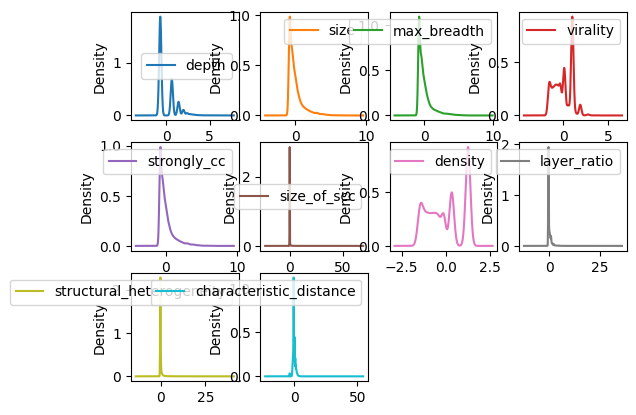

In [12]:
import matplotlib.pyplot as plt
scaled_X_train.plot(kind='density', subplots=True, layout=(3,4), sharex=False, sharey=False)
plt.show()

C:\Users\siddiquee\AppData\Local\Temp\ipykernel_13828\125237508.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  box_plot.set_xticklabels(box_plot.get_xticklabels(), rotation=30)


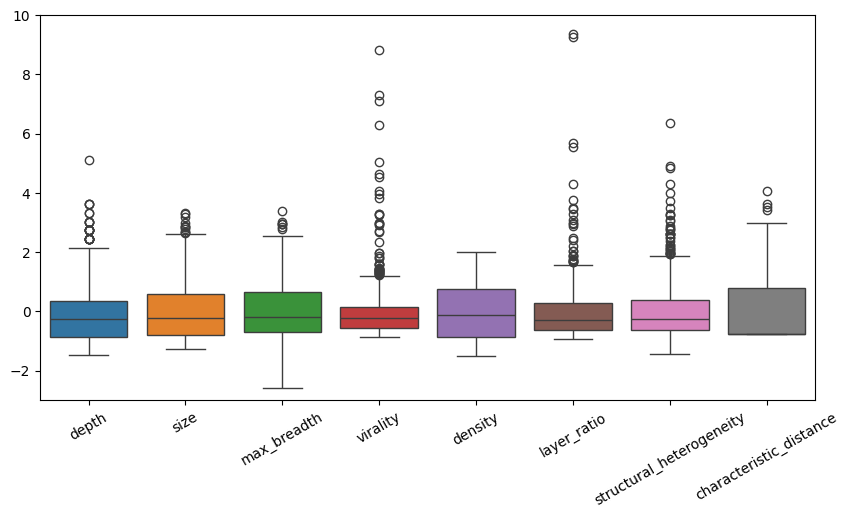

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.cbook import boxplot_stats

d = [boxplot_stats(scaled_X_train[col].dropna().values)[0] for col in scaled_X_train.columns]
s = pd.DataFrame(d, index=scaled_X_train.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)

# sns.set(rc={'figure.figsize':(15, 10)})

fig, ax = plt.subplots(figsize=(10, 5))
ax.set(ylim=(-3, 10))
# directly plot the wide dataframe with only the total_bill data
box_plot = sns.boxplot(data=scaled_X_train, ax=ax)

box_plot.set_xticklabels(box_plot.get_xticklabels(), rotation=30)

plt.savefig(prefix + 'box_plot_after.pdf', format='pdf', bbox_inches='tight')

In [ ]:
s.drop(['mean', 'Var'], axis=1, inplace=True)
# s["mean"]=scaled_X_train.mean()
# s["Var"]=scaled_X_train.var()


# plot

fig, ax = plt.subplots(figsize=(12, 5))
ax.set(ylim=(-2, 8))
# directly plot the wide dataframe with only the total_bill data
box_plot = sns.boxplot(data=scaled_X_train, ax=ax)
box_plot.set_xticklabels(box_plot.get_xticklabels(), rotation=30)

# same plot is created with the primary tips dataframe
# box_plot = sns.boxplot(x="day", y="total_bill", data=tips, ax=ax)

# annotate
for xtick in box_plot.get_xticks():
    for col in s.columns:
        box_plot.text(xtick, s[col][xtick], s[col][xtick], horizontalalignment='left', size='medium', color='k', weight='semibold', bbox=dict(facecolor='lightgray'))


In [ ]:
columns = ['cascade_id','depth','size','max_breadth','virality','strongly_cc','weakly_cc','size_of_scc','avg_cluster_coef','density','layer_ratio','structural_heterogeneity','characteristic_distance','veracity']
vosoughi_df[vosoughi_df.virality.isna() == True][columns].to_csv('./trial.csv', sep=',', encoding='utf-8')


In [6]:
filtered_df[filtered_df.virality.isna() == False]

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
50748,666884.0,50748.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50749,666886.0,50749.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50750,666889.0,50750.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50751,666891.0,50751.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50752,666893.0,50752.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6144,4022213.0,88733.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0
6145,4022215.0,88734.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0
6146,4022217.0,88735.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0
6147,4022219.0,88736.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0


# Feature Selection

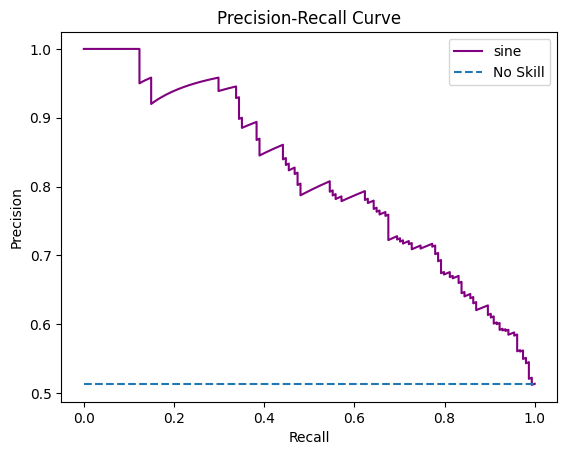

In [38]:
import io
from PIL import Image
import os
import wandb
import matplotlib.pyplot as plt
#calculate precision and recall

# os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
# os.environ["WANDB_ENTITY"]="istiyaksiddiquee"
# wandb.init(project="my-scikit-integration")

precision, recall, thresholds = precision_recall_curve(y_test, y_score)
y_test
no_skill = len(y_test[y_test==1]) / len(y_test)

#create precision recall curve
fig, ax = plt.subplots()

ax.plot(recall, precision, color='purple', label="sine")
ax.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

#add axis labels to plot
ax.set_title('Precision-Recall Curve')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')
ax.legend()
plt.show()
#display plot
# wandb.log({"PRC-2": fig})

# # plt.savefig('PR-test.jpeg')


# img_buf = io.BytesIO()
# plt.savefig(img_buf, format='png')

# im = Image.open(img_buf)
# # im.show(title="My Image")
# wandb.log({"example-2": wandb.Image(im)})
# img_buf.close()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'depth'),
  Text(1.5, 0, 'size'),
  Text(2.5, 0, 'max_breadth'),
  Text(3.5, 0, 'virality'),
  Text(4.5, 0, 'density'),
  Text(5.5, 0, 'layer_ratio'),
  Text(6.5, 0, 'structural_heterogeneity'),
  Text(7.5, 0, 'characteristic_distance')])

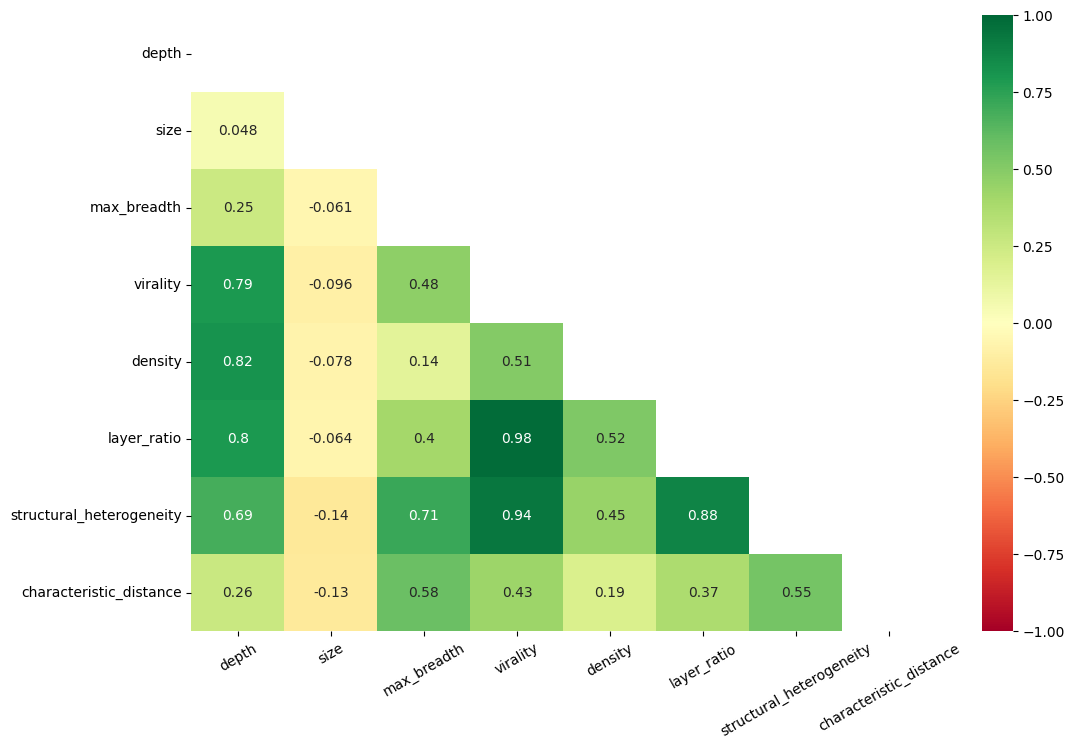

In [75]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(scaled_X_train.corr(), dtype=bool))
sns.heatmap(scaled_X_train.corr(method='pearson', numeric_only = True), annot=True, mask=mask, vmin=-1, vmax=1, cmap ='RdYlGn')
plt.xticks(rotation=30) 
# plt.savefig(prefix + 'pearson_all_features.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

In [78]:
# load statmodels functions
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the vif for all given features
def compute_vif(df, considered_features):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

considered_features = list(scaled_X_train.columns)
# considered_features.remove('max_breadth')
# considered_features.remove('density')
considered_features.remove('virality')

# considered_features.remove('size')
# considered_features.remove('size_of_scc')

# compute vif 
compute_vif(scaled_X_train, considered_features).sort_values('VIF', ascending=False)

,Variable,VIF
5,structural_heterogeneity,14.215249
4,layer_ratio,9.169104
0,depth,8.398339
3,density,4.002522
2,max_breadth,3.948071
6,characteristic_distance,1.628357
1,size,1.238328


In [79]:
scaled_X_train.columns

Index(['depth', 'size', 'max_breadth', 'virality', 'density', 'layer_ratio',
       'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')

PermissionError: [Errno 13] Permission denied: '../datasets-for-exp/RQ4Final1/RQ4Final1_pearson_selected_features.pdf'

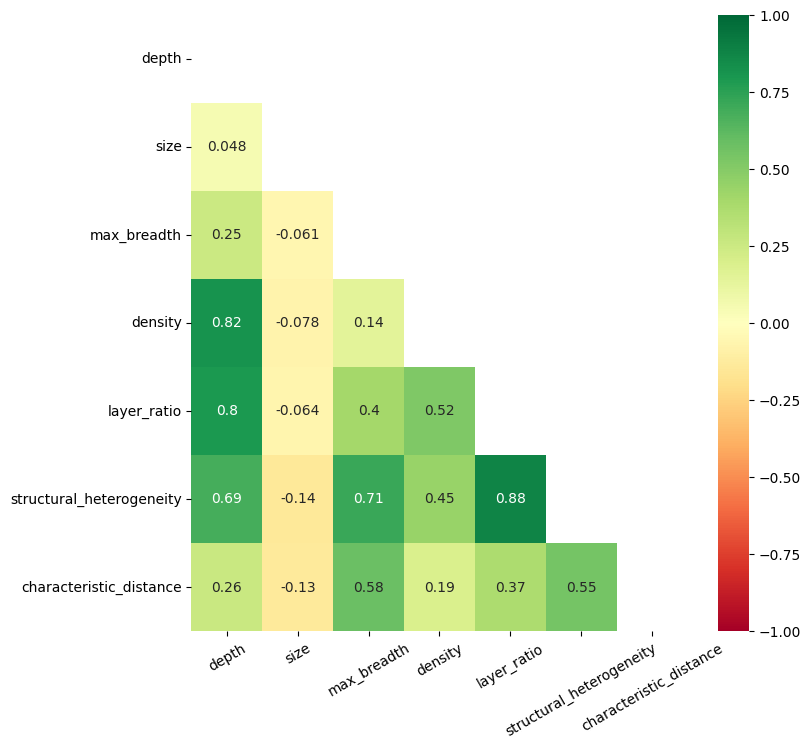

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = ['depth', 'size', 'max_breadth', 'density', 'layer_ratio', 'structural_heterogeneity', 'characteristic_distance']
plt.figure(figsize=(8, 8))
mask = np.triu(np.ones_like(scaled_X_train[columns].corr(), dtype=bool))
sns.heatmap(scaled_X_train[columns].corr(method='pearson', numeric_only = True), annot=True, mask=mask, vmin=-1, vmax=1, cmap ='RdYlGn')
plt.xticks(rotation=30) 
plt.savefig(prefix + 'pearson_selected_features.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso, LogisticRegression

scaler = StandardScaler()
scaler.fit(scaled_X_train[columns])
sel_ = SelectFromModel(LogisticRegression(C=0.5, penalty='l1', solver='liblinear', random_state=10))
sel_.fit(scaler.transform(scaled_X_train[columns]), y_train_val)
removed_feats = scaled_X_train[columns].columns[(sel_.estimator_.coef_ == 0).ravel().tolist()]
removed_feats

Index([], dtype='object')

In [14]:
columns

['depth',
 'virality',
 'density',
 'layer_ratio',
 'structural_heterogeneity',
 'characteristic_distance']

In [15]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rfe_selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=len(columns)-1, step=1, verbose=5)
rfe_selector.fit(scaled_X_train[columns], y_train_val)
rfe_support = rfe_selector.get_support()
rfe_feature = scaled_X_train[columns].loc[:,rfe_support].columns.tolist()
print(str(len(rfe_feature)), 'selected features')
print(rfe_feature)

Fitting estimator with 6 features.
5 selected features
['virality', 'density', 'layer_ratio', 'structural_heterogeneity', 'characteristic_distance']


c:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
270 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1194, in fit
    

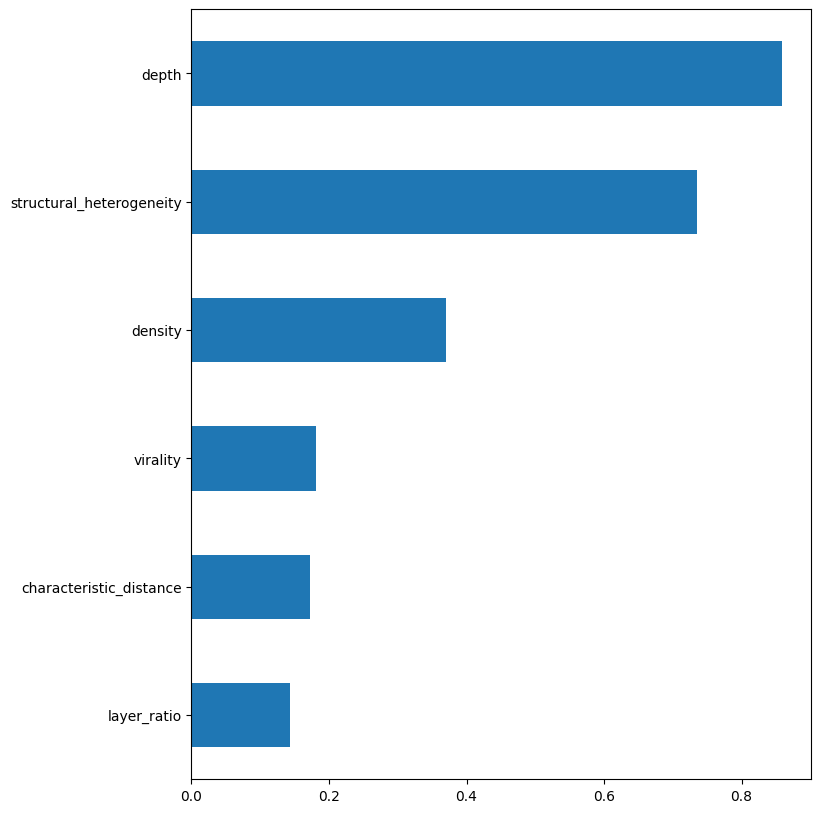

In [16]:
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib
import pandas as pd 

clf_grid = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "C": [_ for _ in range(1, 10, 1)],
    "dual": [True, False],
}

model = LogisticRegression()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=clf_grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train[columns].values, y_train_val.values)
coefficients = np.abs(clf.best_estimator_.coef_)

coef = pd.Series(coefficients[0], index = scaled_X_train[columns].columns)
coef = pd.concat([coef.sort_values().head(10)])


matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
coef.plot(kind = "barh")
# plt.title("Coefficients in the Logistic Model")
plt.savefig(prefix + 'logistic_feature.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

c:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.730e+01, tolerance: 3.745e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

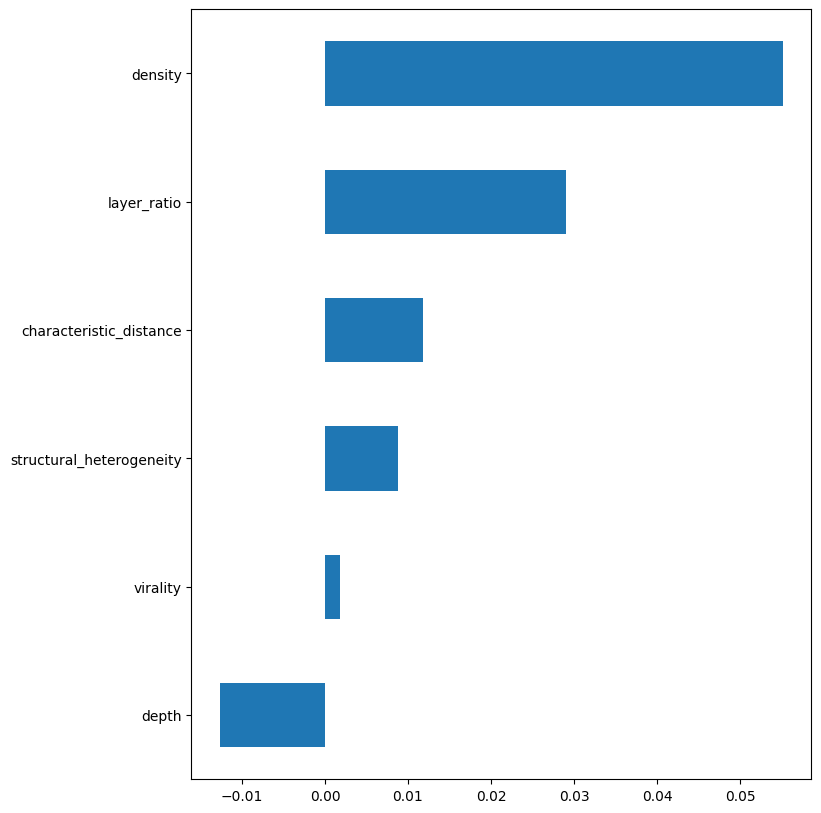

In [17]:
from sklearn.linear_model import ElasticNet
import matplotlib
import matplotlib.pyplot as plt
from numpy import arange

grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0],
    'l1_ratio': arange(0, 1, 0.1)
}

model = ElasticNet()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train[columns], y_train_val)

coef = pd.Series(clf.best_estimator_.coef_, index = scaled_X_train[columns].columns)
imp_coef = pd.concat([coef.sort_values().head(10)])

matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
# plt.title("Coefficients in the Elastic Net Model")
plt.savefig(prefix + 'elastic_feature.pdf', format='pdf', bbox_inches='tight', pad_inches=0.5)

In [19]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# define random forest classifier
rfc = RandomForestClassifier()
boruta_selector = BorutaPy(rfc, n_estimators='auto', verbose=2, random_state=1, max_iter=500)
boruta_selector.fit(np.array(scaled_X_train[columns]), np.array(y_train_val)) 

selected_rf_features = pd.DataFrame({'Feature':list(scaled_X_train[columns].columns),
                                      'Ranking':boruta_selector.ranking_})
selected_rf_features.sort_values(by='Ranking')

Iteration: 	1 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	2 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	3 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	4 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	5 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	6 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	7 / 500
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	8 / 500
Confirmed: 	0
Tentative: 	5
Rejected: 	1
Iteration: 	9 / 500
Confirmed: 	0
Tentative: 	5
Rejected: 	1
Iteration: 	10 / 500
Confirmed: 	0
Tentative: 	5
Rejected: 	1
Iteration: 	11 / 500
Confirmed: 	0
Tentative: 	5
Rejected: 	1
Iteration: 	12 / 500
Confirmed: 	1
Tentative: 	3
Rejected: 	2
Iteration: 	13 / 500
Confirmed: 	1
Tentative: 	3
Rejected: 	2
Iteration: 	14 / 500
Confirmed: 	1
Tentative: 	3
Rejected: 	2
Iteration: 	15 / 500
Confirmed: 	1
Tentative: 	3
Rejected: 	2
Iteration: 	16 / 500
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	17 / 

,Feature,Ranking
2,density,1
3,layer_ratio,1
1,virality,2
4,structural_heterogeneity,3
5,characteristic_distance,4
0,depth,5


In [35]:
print (boruta_selector.n_features_)

0


In [ ]:
feature_selection_df = pd.DataFrame({'Feature':feature_name, 'Pearson':cor_support, 'Chi-2':chi_support, 'RFE':rfe_support, 'Logistics':embeded_lr_support,
                                    'Random Forest':embeded_rf_support, 'LightGBM':embeded_lgb_support})
# count the selected times for each feature
feature_selection_df['Total'] = np.sum(feature_selection_df, axis=1)
# display the top 100
feature_selection_df = feature_selection_df.sort_values(['Total','Feature'] , ascending=False)
feature_selection_df.index = range(1, len(feature_selection_df)+1)
feature_selection_df.head(num_feats)

In [ ]:
considered_features = ['max_breadth', 'density', 'virality', 'depth', 'structural_heterogeneity', 'characteristic_distance', 'size_of_scc', 'layer_ratio']

# Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
 
# To scale data
scaled_X_train = scaler.fit_transform(X_train)

In [ ]:
features = load_diabetes()['feature_names']
pipeline = Pipeline([
                     ('scaler',StandardScaler()),
                     ('model',Lasso())
])
search = GridSearchCV(pipeline,
                      {'model__alpha':np.arange(0.1,10,0.1)},
                      cv = 5, scoring="neg_mean_squared_error",verbose=3
                      )
search.fit(X_train,y_train)
search.best_params_
coefficients = search.best_estimator_.named_steps['model'].coef_

importance = np.abs(coefficients)
np.array(features)[importance > 0]
np.array(features)[importance == 0]

In [3]:
import numpy as np

lgb_grid = {
        "max_depth": [_ for _ in np.arange(1, 10+3, 3)],
        "lambda_l1": [_ for _ in np.arange(1, 10+2, 2)],
        "lambda_l2": [_ for _ in np.arange(1, 10+2, 2)],
        "num_leaves": [_ for _ in np.arange(50, 80+15, 15)],
        "learning_rate": [_ for _ in np.arange(0.1, 1+0.1, 0.2)],
        "min_data_in_leaf": [_ for _ in np.arange(50, 250+50, 50)],
        "min_gain_to_split": [_ for _ in np.arange(0.1, 1+0.2, 0.2)],
}

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(lgb_grid)
len(pg)

64800

In [6]:
len([_ for _ in np.arange(1, 30 + 5, 5)])

7

In [6]:
import numpy as np
xgb_grid = {   
        # "gamma": [_ for _ in np.arange(0.1, 1+0.1, 0.1)],
        "subsample": [_ for _ in np.arange(0.2, 1 + 0.2, 0.2)],
        "max_depth": [_ for _ in np.arange(1, 30 + 10, 10)],
        "reg_alpha": [_ for _ in np.arange(1, 10 + 2, 2)],
        "reg_lambda": [_ for _ in np.arange(1, 10 + 2, 2)],
        "n_estimators": [_ for _ in np.arange(100, 250+50, 50)],
        "learning_rate": [_ for _ in np.arange(0.1, 1 + 0.2, 0.2)],
        # "colsample_bytree": [_ for _ in np.arange(0.2, 0.9+0.1, 0.1)],
        "min_child_weight": [_ for _ in np.arange(1, 7+2, 2)],
}

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(xgb_grid)
len(pg)

69120

In [1]:
import numpy as np
len([_ for _ in np.arange(0.005, 0.1+0.01, 0.01)])

11

In [8]:
dt_grid = {
    "max_depth": [_ for _ in np.arange(1, 40 + 5, 5)],
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [_ for _ in np.arange(1, 40 + 5, 5)],
    "min_samples_leaf": [_ for _ in np.arange(1, 30 + 5, 5)],
    "min_impurity_decrease": [_ for _ in np.arange(0.005, 0.1+0.01, 0.01)]
}

len(ParameterGrid(dt_grid))


12474

In [18]:
len([_ for _ in np.arange(1, 40 + 1, 1)])

40

In [11]:
len([_ for _ in np.arange(2, 30 + 5, 5)])

7

In [11]:
rf_grid = {
    "max_depth": [_ for _ in np.arange(1, 50 + 10, 10)],
    "n_estimators": [_ for _ in np.arange(50, 500 + 100, 100)],
    "max_features": ['sqrt', 'log2'], 
    "min_samples_leaf": [_ for _ in np.arange(1, 30 + 5, 5)],
    "min_samples_split": [_ for _ in np.arange(2, 30 + 5, 5)],
    "criterion": ["gini", "entropy", "log_loss"],
    "min_impurity_decrease": [_ for _ in np.arange(0.005, 0.1+0.02, 0.02)]
}

len(ParameterGrid(rf_grid))

63504

In [6]:
logit_grid = {
            "penalty": ["l1", "l2", "elasticnet"],
            "dual": [True, False],
            "C": [_ for _ in range(1, 11, 1)],
            "fit_intercept": [True, False],
            "max_iter": [500],
            "solver": ["lbfgs", "newton-cg", "sag", "saga"],
            "n_jobs": [-1],
        }

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(logit_grid)
len(pg)

480

In [4]:
for i in range(1, 11, 1):
    print(i)

1
2
3
4
5
6
7
8
9
10


In [1]:
import pickle
file_path = './image'
with open(file_path + "/x_train_val.pickle", "rb") as file:
    X_train_val = pickle.load(file)
    
X_train_val.shape

(32305, 8)

In [2]:
X_train_val

,depth,max_breadth,virality,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
76742,2.0,15.0,0.076316,20.0,0.050000,1.333333,1.807954,1.444840
65438,1.0,4.0,0.250000,4.0,0.250000,1.000000,1.154701,3.497332
77936,3.0,12.0,0.104575,18.0,0.055556,1.416667,1.578401,1.031867
62375,1.0,3.0,0.333333,3.0,0.333333,1.000000,1.060660,2.466303
67452,1.0,5.0,0.200000,5.0,0.200000,1.000000,1.250000,4.445556
...,...,...,...,...,...,...,...,...
53331,1.0,2.0,0.500000,2.0,0.500000,1.000000,1.000000,1.439579
2282,2.0,2.0,0.666667,3.0,0.333333,1.500000,1.060660,1.819785
64675,1.0,4.0,0.250000,4.0,0.250000,1.000000,1.154701,3.497332
51667,1.0,2.0,0.500000,2.0,0.500000,1.000000,1.000000,1.439579


# DS2

In [7]:
len([_ for _ in np.arange(0.2, 1 + 0.2, 0.2)])

5

In [27]:
xgb_grid = {   
        # "gamma": [_ for _ in np.arange(0.1, 1+0.1, 0.1)],
        # "subsample": [_ for _ in np.arange(0.2, 1 + 0.2, 0.2)],
        "max_depth": [_ for _ in np.arange(1, 30 + 10, 10)],
        # "reg_alpha": [_ for _ in np.arange(1, 10 + 2, 2)],
        "reg_lambda": [_ for _ in np.arange(1, 10 + 2, 2)],
        "n_estimators": [_ for _ in np.arange(100, 250+50, 50)],
        "learning_rate": [_ for _ in np.arange(0.1, 1 + 0.2, 0.2)],
        # "colsample_bytree": [_ for _ in np.arange(0.2, 0.9+0.1, 0.1)],
        "min_child_weight": [_ for _ in np.arange(1, 7+2, 2)],
}


from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(xgb_grid)
len(pg)

2304

In [28]:
xgb_grid = {   
    # "gamma": [_ for _ in np.arange(0.1, 1+0.1, 0.1)],
    # "subsample": [_ for _ in np.arange(0.2, 1 + 0.2, 0.2)],
    "max_depth": [_ for _ in np.arange(1, 10 + 2, 2)],
    # "reg_alpha": [_ for _ in np.arange(1, 10 + 2, 2)],
    "reg_lambda": [_ for _ in np.arange(1, 10 + 2, 2)],
    "n_estimators": [_ for _ in np.arange(100, 300+100, 100)],
    "learning_rate": [_ for _ in np.arange(0.1, 1 + 0.2, 0.2)],
    "min_child_weight": [_ for _ in np.arange(1, 7+2, 2)],
}

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(xgb_grid)
len(pg)

2592

In [17]:
len([_ for _ in np.arange(0.1, 1+0.3, 0.3)])

4

In [31]:
lgb_grid = {
        "max_depth": [_ for _ in np.arange(1, 10+3, 3)],
        # "lambda_l1": [_ for _ in np.arange(1, 10+2, 2)],
        "lambda_l2": [_ for _ in np.arange(1, 10+3, 3)],
        "num_leaves": [_ for _ in np.arange(50, 80+15, 15)],
        "learning_rate": [_ for _ in np.arange(0.1, 1+0.3, 0.3)],
        "min_data_in_leaf": [_ for _ in np.arange(50, 250+50, 50)],
        "min_gain_to_split": [_ for _ in np.arange(0.1, 1+0.3, 0.3)],
}

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(lgb_grid)
len(pg)

3840

In [32]:
lgb_grid = {
    "max_depth": [_ for _ in np.arange(1, 10+3, 3)],
    # "lambda_l1": [_ for _ in np.arange(1, 10+2, 2)],
    "lambda_l2": [_ for _ in np.arange(1, 10+3, 3)],
    "num_leaves": [_ for _ in np.arange(50, 80+15, 15)],
    "learning_rate": [_ for _ in np.arange(0.1, 1+0.3, 0.3)],
    "min_data_in_leaf": [_ for _ in np.arange(10, 30+15, 15)],
    "min_gain_to_split": [_ for _ in np.arange(0.1, 1+0.2, 0.2)],
}
from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(lgb_grid)
len(pg)

3456

In [35]:
rf_grid = {
        "max_depth": [_ for _ in np.arange(1, 50 + 15, 15)],
        "n_estimators": [_ for _ in np.arange(50, 500 + 100, 100)],
        # "max_features": ['sqrt', 'log2', None], 
        "min_samples_leaf": [_ for _ in np.arange(1, 30 + 10, 10)],
        "min_samples_split": [_ for _ in np.arange(2, 30 + 5, 5)],
        "criterion": ["entropy"],
        "min_impurity_decrease": [_ for _ in np.arange(0.005, 0.1+0.04, 0.04)]
}


from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(rf_grid)
len(pg)

3360

In [36]:
rf_grid = {
        "max_depth": [_ for _ in np.arange(1, 20 + 5, 5)],
        "n_estimators": [_ for _ in np.arange(50, 300 + 100, 100)],
        # "max_features": ['sqrt', 'log2', None], 
        "min_samples_leaf": [_ for _ in np.arange(1, 20 + 5, 5)],
        "min_samples_split": [_ for _ in np.arange(2, 20 + 5, 5)],
        # "criterion": ["entropy"],
        "min_impurity_decrease": [_ for _ in np.arange(0.005, 0.1+0.02, 0.02)]
}


from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(rf_grid)
len(pg)

3000

In [38]:
import numpy as np

dt_grid = {
    "max_depth": [_ for _ in np.arange(1, 40 + 10, 10)],
    # "max_features": ['sqrt', 'log2', None],
    "min_samples_split": [_ for _ in np.arange(1, 40 + 5, 5)],
    "min_samples_leaf": [_ for _ in np.arange(1, 30 + 5, 5)],
    "min_impurity_decrease": [_ for _ in np.arange(0.005, 0.1+0.02, 0.02)]
}


from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(dt_grid)
len(pg)

1890

In [41]:
dt_grid = {
    "max_depth": [_ for _ in np.arange(1, 20 + 5, 5)],
    # "max_features": ['sqrt', 'log2', None],
    "min_samples_leaf": [_ for _ in np.arange(1, 15 + 3, 3)],
    "min_samples_split": [_ for _ in np.arange(1, 10 + 1, 1)],
    "min_impurity_decrease": [_ for _ in np.arange(0.005, 0.1+0.02, 0.02)]
}

from sklearn.model_selection import ParameterGrid

pg = ParameterGrid(dt_grid)
len(pg)

1800

In [2]:
import pickle 
import os 
import pandas

X_train_val_file_name = "./image/x_train_val.pickle"

with open(X_train_val_file_name, "rb") as file:
    X_train_val = pickle.load(file)
    print(len(X_train_val.columns))
    print(X_train_val.columns)


8
Index(['depth', 'max_breadth', 'virality', 'size_of_scc', 'density',
       'layer_ratio', 'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')


In [4]:
import os 

os.getcwd()

'e:\\Fake News Project\\thesis work\\RQ2'

In [46]:
import pandas as pd 

df = pd.read_csv('../../Datasets/FalseNews_Code_Data/data/raw_data_anon.csv')


C:\Users\siddiquee\AppData\Local\Temp\ipykernel_4644\1259487315.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../Datasets/FalseNews_Code_Data/data/raw_data_anon.csv')


In [47]:
df.cascade_id.nunique()

126302

In [36]:
result = df.groupby(['cascade_id', 'user_account_age']).size().reset_index(name='cnt')


In [38]:
result[result.cnt >= 10].to_csv('./test.csv')

In [39]:
result[result.cnt > 10]

,cascade_id,user_account_age,cnt
158938,76036,1799.0,22
215788,78923,895.0,22
247840,79696,124.0,11
277767,80183,315.0,14
277768,80183,379.0,13
...,...,...,...
1957770,126301,1315.0,11
1957775,126301,1320.0,12
1957783,126301,1328.0,11
1957962,126301,1507.0,11


In [41]:
result.cnt.max()

263

In [35]:
result.groupby(['cnt'])['cascade_id'].count().to_csv('./same_user_age_count.csv')

In [1]:
import pandas as pd 

df = pd.read_csv('./rq2_fibvid_features.csv')
df

,Unnamed: 0,cascade_root_id,category,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
0,0,1288771853822103552,covid_true,2.0,7.0,6.0,0.190476,7.0,1.0,7.0,0.0,0.142857,1.166667,1.285604,1.024628,1.0
1,1,1251209120528637952,covid_true,1.0,142.0,142.0,0.007042,142.0,1.0,142.0,0.0,0.007042,1.000000,5.979279,124.999346,1.0
2,2,1238131956526784512,covid_true,0.0,1.0,1.0,NaN,1.0,1.0,1.0,0.0,0.000000,1.000000,0.000000,-99999.000000,1.0
3,3,1262244018198441984,covid_true,2.0,20.0,17.0,0.065789,20.0,1.0,20.0,0.0,0.050000,1.176471,2.004151,1.051074,1.0
4,4,1273140209090203651,covid_true,2.0,121.0,102.0,0.010882,121.0,1.0,121.0,0.0,0.008264,1.186275,4.690253,1.079731,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1769,1769,1225294960087486464,non_covid_false,2.0,107.0,99.0,0.010756,107.0,1.0,107.0,0.0,0.009346,1.080808,4.815929,0.756799,0.0
1770,1770,1248416686220300298,non_covid_false,1.0,22.0,22.0,0.045455,22.0,1.0,22.0,0.0,0.045455,1.000000,2.400397,20.829333,0.0
1771,1771,1224930570985144322,non_covid_false,1.0,31.0,31.0,0.032258,31.0,1.0,31.0,0.0,0.032258,1.000000,2.829900,31.247336,0.0
1772,1772,1273769391461560320,non_covid_false,2.0,78.0,70.0,0.015485,78.0,1.0,78.0,0.0,0.012821,1.114286,4.006236,0.877097,0.0


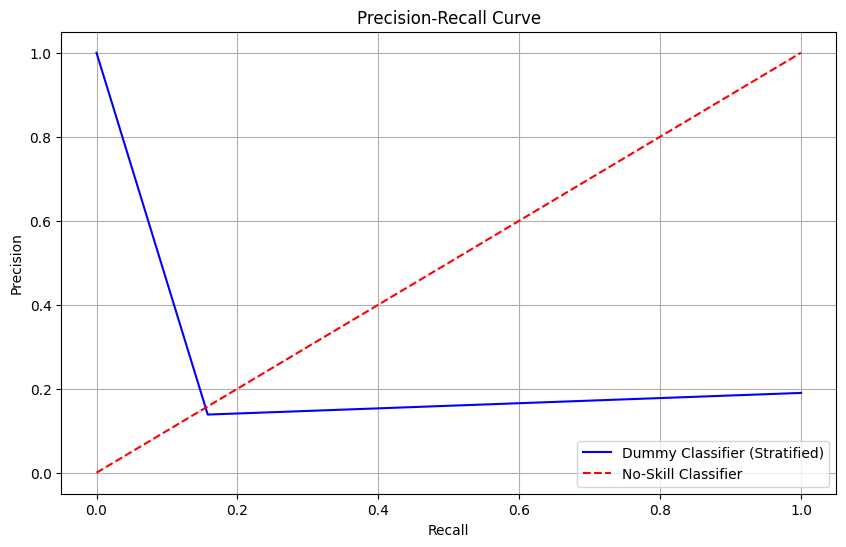

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.dummy import DummyClassifier

# Create an imbalanced dataset with 1:4 ratio
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, 
                           weights=[0.8, 0.2], flip_y=0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train, y_train)
y_scores_dummy = dummy_clf.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

precision_dummy, recall_dummy, _ = precision_recall_curve(y_test, y_scores_dummy)

# No-skill classifier (random guessing)
no_skill_precision = np.linspace(0, 1, num=len(recall_dummy))
no_skill_recall = np.linspace(0, 1, num=len(recall_dummy))

plt.figure(figsize=(10, 6))
plt.plot(recall_dummy, precision_dummy, label='Dummy Classifier (Stratified)', color='blue')
plt.plot(no_skill_recall, no_skill_precision, label='No-Skill Classifier', linestyle='--', color='red')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

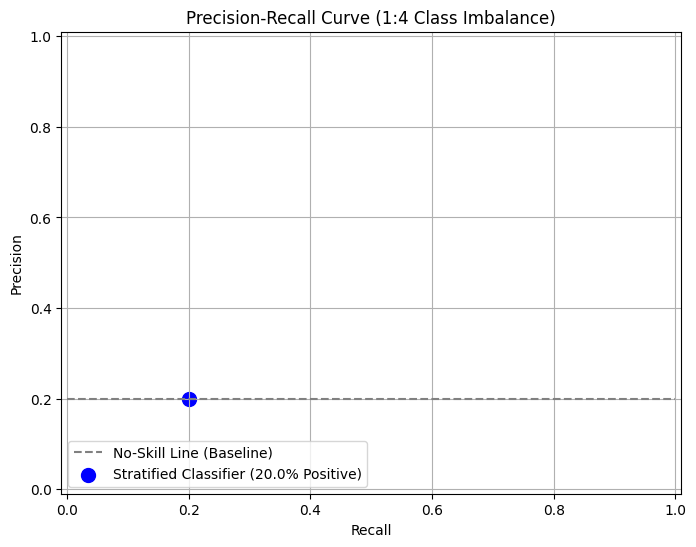

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Class Prevalence (Positive class proportion) for 1:4 imbalance
positive_prevalence = 1/5  # 20% Positive, 80% Negative

# No-Skill Line (Baseline) - Recall values from 0 to 1
recall_ns = np.linspace(0, 1, 100)
precision_ns = positive_prevalence * np.ones_like(recall_ns)  # Constant precision for No-Skill Line

# Stratified Classifier Performance
recall_stratified = positive_prevalence
precision_stratified = positive_prevalence

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(recall_ns, precision_ns, label='No-Skill Line (Baseline)', linestyle='--', color='gray')
plt.scatter(recall_stratified, precision_stratified, label=f"Stratified Classifier ({positive_prevalence*100:.1f}% Positive)", color='blue', s=100)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (1:4 Class Imbalance)')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

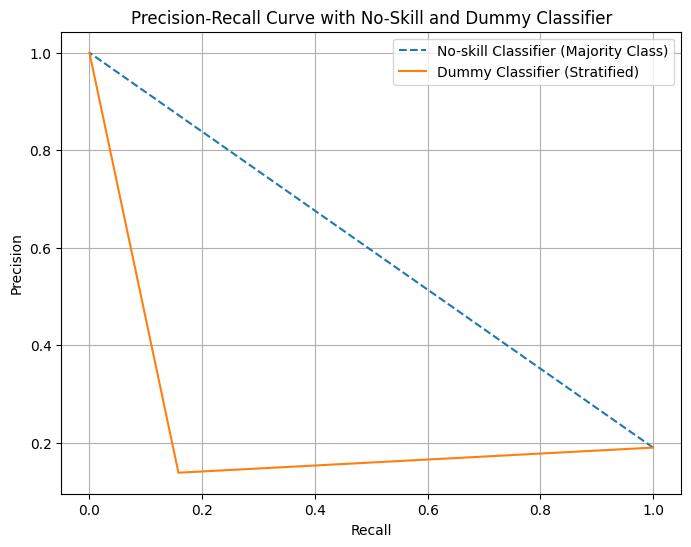

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Create an imbalanced dataset with 1:4 class distribution
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.8, 0.2],
                           random_state=42, flip_y=0)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a no-skill classifier that predicts the majority class
no_skill_probs = [0 for _ in range(len(y_test))]
# Calculate the precision-recall curve for a no-skill classifier
no_skill_precision, no_skill_recall, _ = precision_recall_curve(y_test, no_skill_probs)

# Define a dummy classifier with 'stratified' strategy
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train, y_train)
y_probs_dummy = dummy_clf.predict_proba(X_test)[:, 1]
# Calculate the precision-recall curve for dummy classifier
dummy_precision, dummy_recall, _ = precision_recall_curve(y_test, y_probs_dummy)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(no_skill_recall, no_skill_precision, linestyle='--', label='No-skill Classifier (Majority Class)')
plt.plot(dummy_recall, dummy_precision, label='Dummy Classifier (Stratified)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with No-Skill and Dummy Classifier')
plt.legend()
plt.grid(True)
plt.show()
